# Sampling 3D Matérn random fields on two reservoir models

This notebook builds **full-3D Matérn SPDE precision matrices** on two corner-point reservoir grids and draws samples from the implied Gaussian priors $\mathcal{N}(0, Q^{-1})$:

- **Example 1 — SPE9** (9 000 active cells, field units / feet)
- **Example 2 — NORNE** (44 417 active cells, UTM metres)
- **Example 3 — target standard deviation $\sigma = 10$**: we check that both models reach a prescribed marginal standard deviation, not just the default $\sigma = 1$.

For each model we run the same suite of experiments:
1. an **isotropic** Matérn prior (TPFA discretization), and
2. an **anisotropic, rotated** prior whose anisotropy is confined to the horizontal (x–y) plane via a pure azimuth rotation (avgMPFA discretization).

The Matérn operator uses the Whittle SPDE form
$$Q = D_\tau\, K^{\top} C^{-1} K\, D_\tau, \qquad K = L_H + \mathrm{diag}(V\kappa^2),$$
with finite-volume mass matrix $C=\mathrm{diag}(V)$ and a **Robin** boundary correction. See `CONTEXT.md` and the ADRs in `docs/adr/` for the vocabulary and design decisions.

In [1]:
using Jutul
using JutulDarcy
using JutulDarcy.GeoEnergyIO: parse_data_file
using SparseArrays, LinearAlgebra, Statistics, Random
using CairoMakie
CairoMakie.activate!()
set_theme!(theme_minimal())
rng = MersenneTwister(20240601);

## Shared helpers

We factor the pipeline into small reusable pieces so each example below is just one call. `resolve_model_data` finds a `.DATA` file from a few candidate locations (set the matching `ENV` key to override). `field_to_grid` maps an active-cell vector onto the logical `(ni, nj, nk)` grid, and `sample_prior` draws samples via the sparse Cholesky factorization of $Q$.

In [2]:
"""Locate a model .DATA file from ENV or candidate relative paths."""
function resolve_model_data(env_key::AbstractString, filename::AbstractString, subdir::AbstractString)
    has(p) = !isempty(p) && isfile(p)
    candidates = String[
        get(ENV, env_key, ""),
        normpath(@__DIR__, "..", "..", "..", "..", "..", "models", "opm-tests", subdir, filename),
        normpath(pwd(), "..", "..", "models", "opm-tests", subdir, filename),
        joinpath(homedir(), "CodeProjects", "makeSENSE", "models", "opm-tests", subdir, filename),
    ]
    for p in candidates
        has(p) && return p
    end
    error("Could not locate $filename. Set ENV[\"$env_key\"] to its path.")
end

function load_domain_quiet(data_path::AbstractString)
    # Parse quietly: NORNE/SPE9 .DATA files emit many harmless 'Unsupported keyword' notices.
    data = redirect_stdout(devnull) do; redirect_stderr(devnull) do; parse_data_file(data_path); end; end
    return reservoir_domain(data)
end

"""Map an active-cell vector onto the (ni,nj,nk) parent grid."""
function field_to_grid(x::AbstractVector, ijk, ni, nj, nk; fillvalue = NaN)
    F = fill(Float64(fillvalue), ni, nj, nk)
    for (c, (i, j, k)) in enumerate(ijk)
        F[i, j, k] = x[c]
    end
    return F
end

"""Draw n samples from N(0, Q^{-1}) via sparse Cholesky of Q."""
function sample_prior(Q, n::Integer; rng = Random.default_rng())
    F = JutulDarcy._factor_precision_matrix(Symmetric(sparse(Q)))
    nq = size(Q, 1)
    X = Matrix{Float64}(undef, nq, n)
    for s in 1:n
        ξ = randn(rng, nq)
        y = F.U \ ξ                 # triangular solve with upper factor
        x = similar(y); x[F.p] .= y  # undo fill-reducing permutation
        X[:, s] = x
    end
    return X
end;

## The experiment runner

`run_matern_example` performs the full suite on one model: it builds the isotropic and the x–y-plane anisotropic operators, samples both, and displays the figures. The anisotropy uses principal ranges $\rho_{\mathrm{major}} > \rho_{\mathrm{minor}}$ in the horizontal plane with `dip = rake = 0` (a pure azimuth rotation about the vertical axis).

In [3]:
function run_matern_example(data_path::AbstractString, name::AbstractString;
        ρ0_frac::Real = 0.25, σ0::Real = 1.0,
        aniso_ratio::Real = 0.35, azimuth_deg::Real = 30.0,
        n_samples::Integer = 25, k_layer = nothing)
    println("=== ", name, " ===")
    domain = load_domain_quiet(data_path)
    nc = number_of_cells(domain)
    cc = Matrix{Float64}(domain[:cell_centroids])
    mesh = physical_representation(domain)
    ijk = [Tuple(cell_ijk(mesh, c)) for c in 1:nc]
    ni = maximum(first, ijk); nj = maximum(x -> x[2], ijk); nk = maximum(last, ijk)
    lx = maximum(cc[1,:]) - minimum(cc[1,:]); ly = maximum(cc[2,:]) - minimum(cc[2,:])
    lz = maximum(cc[3,:]) - minimum(cc[3,:])
    ρ0 = ρ0_frac * min(lx, ly)
    println("active cells = ", nc, "   grid (ni,nj,nk) = ($ni, $nj, $nk)")
    println("lateral extent = $(round(lx,digits=1)) × $(round(ly,digits=1))   vertical = $(round(lz,digits=1))")
    println("ρ0 = ", round(ρ0, digits=1))

    # ---- isotropic prior (TPFA) ----
    prior_iso = MaternSPDE3Prior(nc; ρ0 = ρ0, σ0 = σ0, diffusion_scheme = :tpfa)
    op_iso = matern_spde_operator(domain, prior_iso; compensated = false, boundary = :robin)
    Q = sparse(op_iso.Q)
    var_iso = matern_realized_variance(domain, prior_iso; anchors = :all, compensated = false, boundary = :robin)
    rr = var_iso.realized ./ var_iso.target
    println("isotropic Q nnz = ", nnz(Q), "   realized var/target: mean = ", round(mean(rr), digits=3))
    X = sample_prior(Q, n_samples; rng = rng)
    println("empirical marginal std = ", round(sqrt(mean(var(X, dims = 2))), digits=3))

    kl = isnothing(k_layer) ? nk ÷ 2 : k_layer
    imid = ni ÷ 2
    Fiso = field_to_grid(X[:, 1], ijk, ni, nj, nk)
    fig1 = Figure(size = (900, 360))
    ax1 = Axis(fig1[1,1]; title = "$name — isotropic sample, K-layer $kl",
               xlabel="j", ylabel="i", aspect=DataAspect())
    hm1 = heatmap!(ax1, Fiso[:,:,kl]'; colormap=:viridis); Colorbar(fig1[1,2], hm1)
    ax2 = Axis(fig1[1,3]; title = "$name — vertical I-plane $imid",
               xlabel="k", ylabel="j", aspect=DataAspect())
    hm2 = heatmap!(ax2, Fiso[imid,:,:]'; colormap=:viridis); Colorbar(fig1[1,4], hm2)
    display(fig1)

    # ---- anisotropic prior, x-y plane rotation (avgMPFA) ----
    ρmaj, ρmin, ρv = ρ0, aniso_ratio * ρ0, ρ0
    az = deg2rad(azimuth_deg)
    ρb = (ρmaj * ρmin * ρv)^(1/3)
    basis = MaternBasis(spdiagm(0 => ones(Float64, nc)))
    prior_an = MaternSPDE3Prior(nc; ρ0 = ρb, σ0 = σ0,
        range_x_basis = basis, range_y_basis = basis, range_z_basis = basis,
        sd_basis = basis, azimuth_basis = basis, dip_basis = basis, rake_basis = basis,
        diffusion_scheme = :avgmpfa)
    θ_an = (range_x = fill(log(ρmaj/ρb), nc), range_y = fill(log(ρmin/ρb), nc),
            range_z = fill(log(ρv/ρb), nc), sd = zeros(nc),
            azimuth = fill(az, nc), dip = zeros(nc), rake = zeros(nc))
    print("building avgMPFA anisotropic operator ... "); flush(stdout)
    op_an = matern_spde_operator(domain, prior_an, θ_an; compensated = false, boundary = :robin)
    Qan = sparse(op_an.Q)
    println("done. nnz = ", nnz(Qan),
            "   dip = ", round(rad2deg(mean(op_an.fields.dip)), digits=2),
            "°, rake = ", round(rad2deg(mean(op_an.fields.rake)), digits=2), "°")

    Xan = sample_prior(Qan, n_samples; rng = rng)
    Fan = field_to_grid(Xan[:, 1], ijk, ni, nj, nk)

    # correlation ellipse from a central anchor
    xc = vec(mean(cc, dims = 2)); anchor = argmin([sum(abs2, cc[:,c] .- xc) for c in 1:nc])
    ai, aj, ak = ijk[anchor]
    Fq = JutulDarcy._factor_precision_matrix(Symmetric(Qan))
    e = zeros(Float64, nc); e[anchor] = 1.0
    cov_col = Fq \ e
    corr_like = cov_col ./ cov_col[anchor]
    Cgrid = field_to_grid(corr_like, ijk, ni, nj, nk)

    fig2 = Figure(size = (980, 360))
    axc = Axis(fig2[1,1]; title = "$name — correlation with anchor (K-layer $ak), x-y anisotropy",
               xlabel="j", ylabel="i", aspect=DataAspect())
    hmc = heatmap!(axc, clamp.(Cgrid[:,:,ak]', -0.4, 1.0); colormap=:RdBu_3)
    scatter!(axc, [aj], [ai]; color=:black, markersize=12)
    Colorbar(fig2[1,2], hmc; label="correlation")
    axs = Axis(fig2[1,3]; title = "$name — anisotropic sample (K-layer $ak)",
               xlabel="j", ylabel="i", aspect=DataAspect())
    hms = heatmap!(axs, Fan[:,:,ak]'; colormap=:plasma)
    Colorbar(fig2[1,4], hms; label="field value")
    display(fig2)

    # isotropic vs anisotropic at the anchor's K-layer
    fig3 = Figure(size = (900, 360))
    axA = Axis(fig3[1,1]; title = "$name — isotropic (K-layer $ak)",
               xlabel="j", ylabel="i", aspect=DataAspect())
    hmA = heatmap!(axA, Fiso[:,:,ak]'; colormap=:viridis); Colorbar(fig3[1,2], hmA)
    axB = Axis(fig3[1,3]; title = "$name — x-y anisotropic, azimuth $(round(Int,azimuth_deg))° (K-layer $ak)",
               xlabel="j", ylabel="i", aspect=DataAspect())
    hmB = heatmap!(axB, Fan[:,:,ak]'; colormap=:viridis); Colorbar(fig3[1,4], hmB)
    display(fig3)

    return (name = name, nc = nc, grid = (ni, nj, nk), ρ0 = ρ0,
            ρ_major = ρmaj, ρ_minor = ρmin, azimuth = az)
end;

---
## Example 1 — SPE9

SPE9 is a 24×25×15 corner-point model (≈9 000 active cells) in field units. We use a practical range of 25% of the lateral extent, and an x–y-plane anisotropy with a 30° azimuth.

SPE9 model: /home/AD.NORCERESEARCH.NO/krfo/CodeProjects/makeSENSE/models/opm-tests/spe9/SPE9.DATA
=== 

SPE9 ===
active cells = 

9000   grid (ni,nj,nk) = (24, 25, 15)
lateral extent = 2103.1 × 2194.6   vertical = 462.0
ρ0 = 525.8
isotropic Q nnz = 206566

   realized var/target: mean = 1.396
empirical marginal std = 

1.185


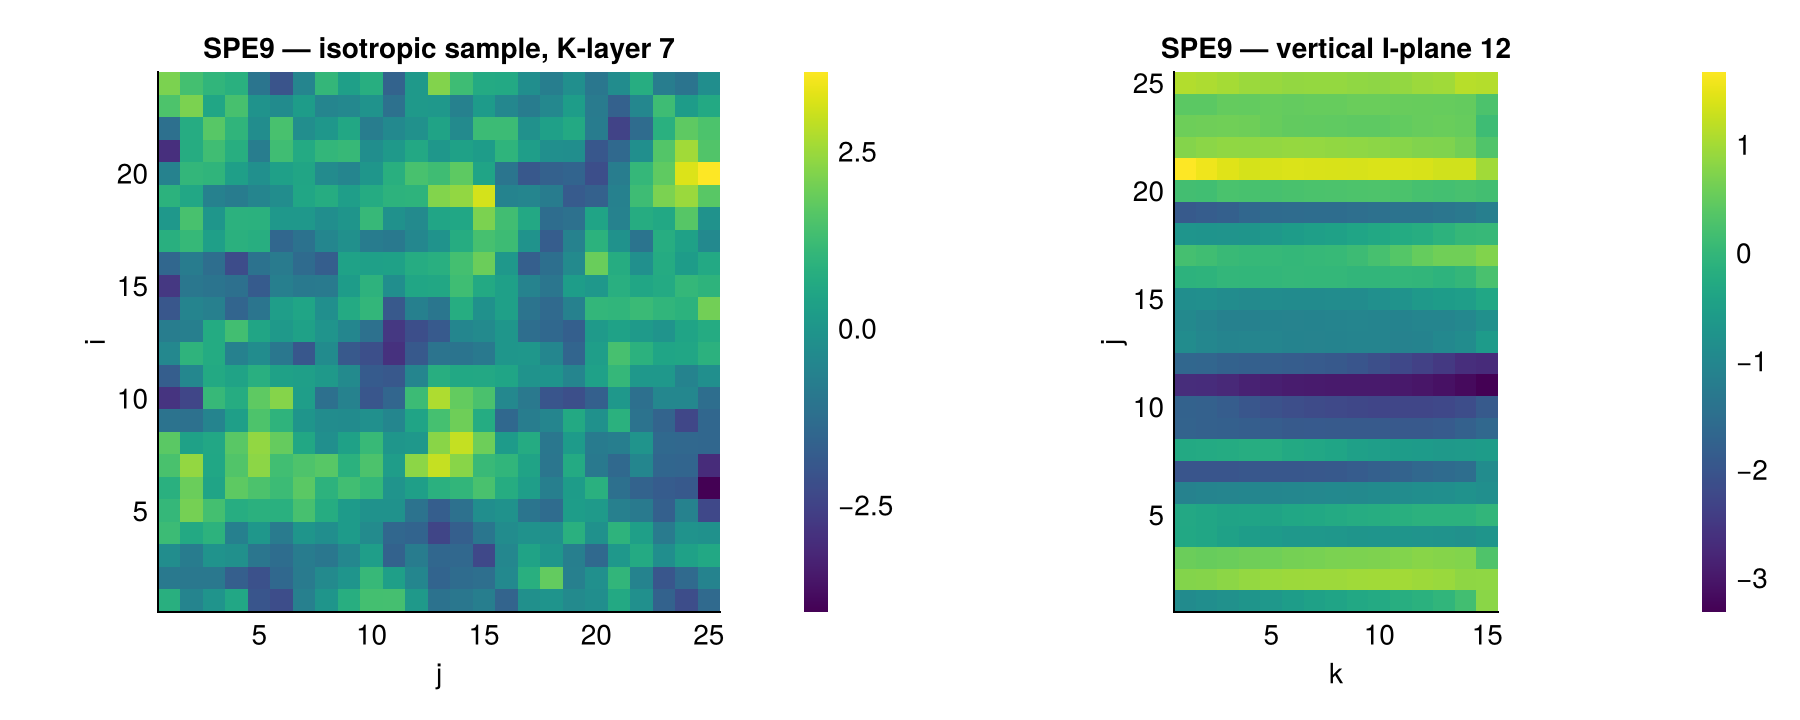

building avgMPFA anisotropic operator ... 

done. nnz = 433206

   dip = 0.0°, rake = 0.0°


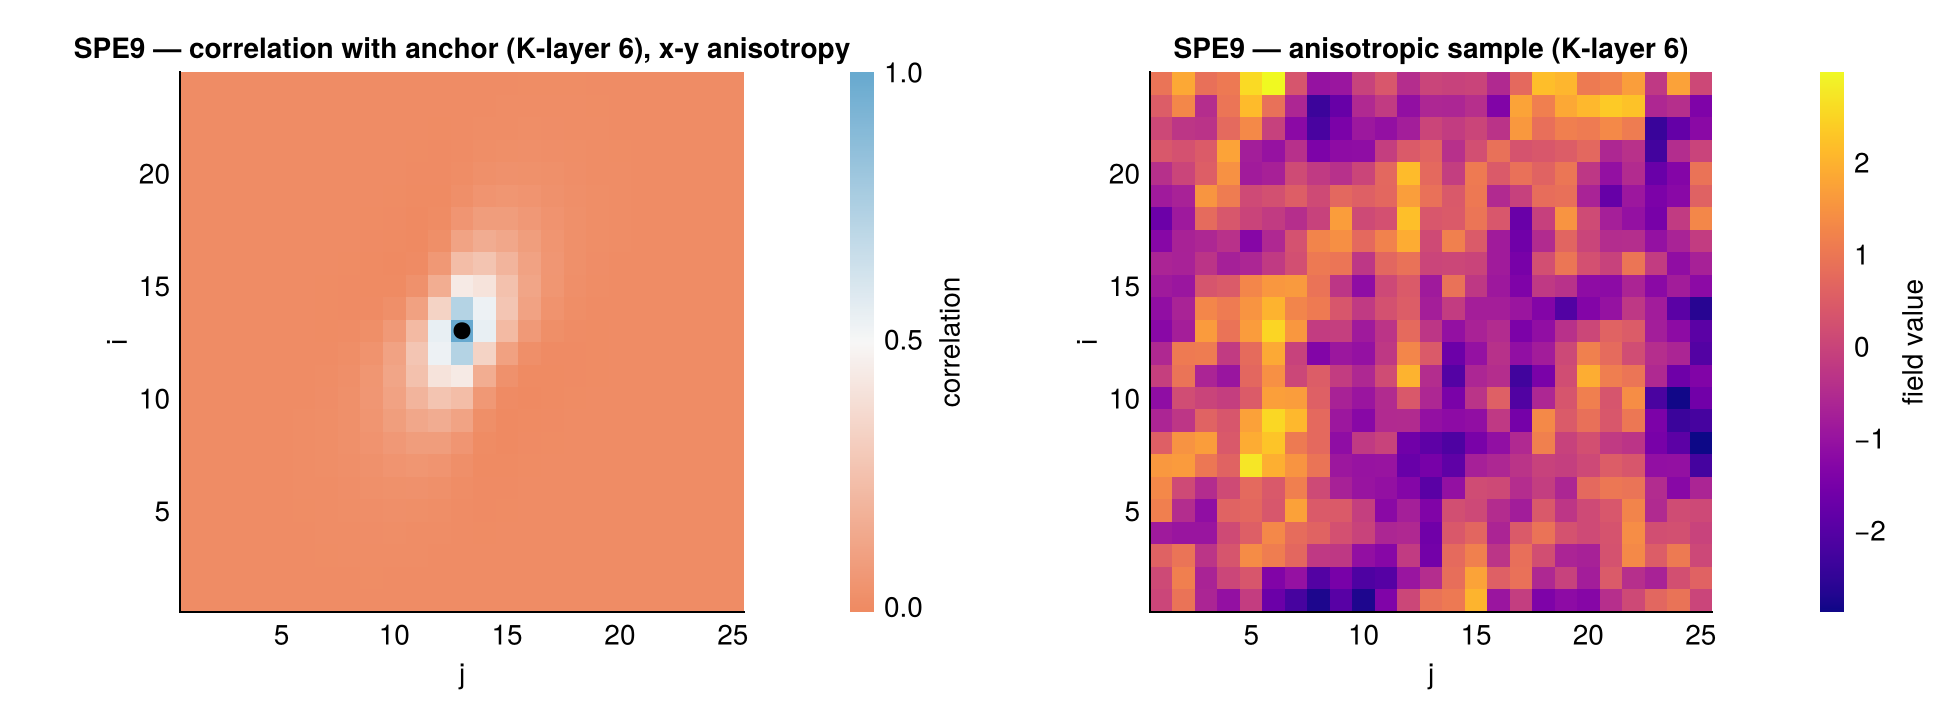

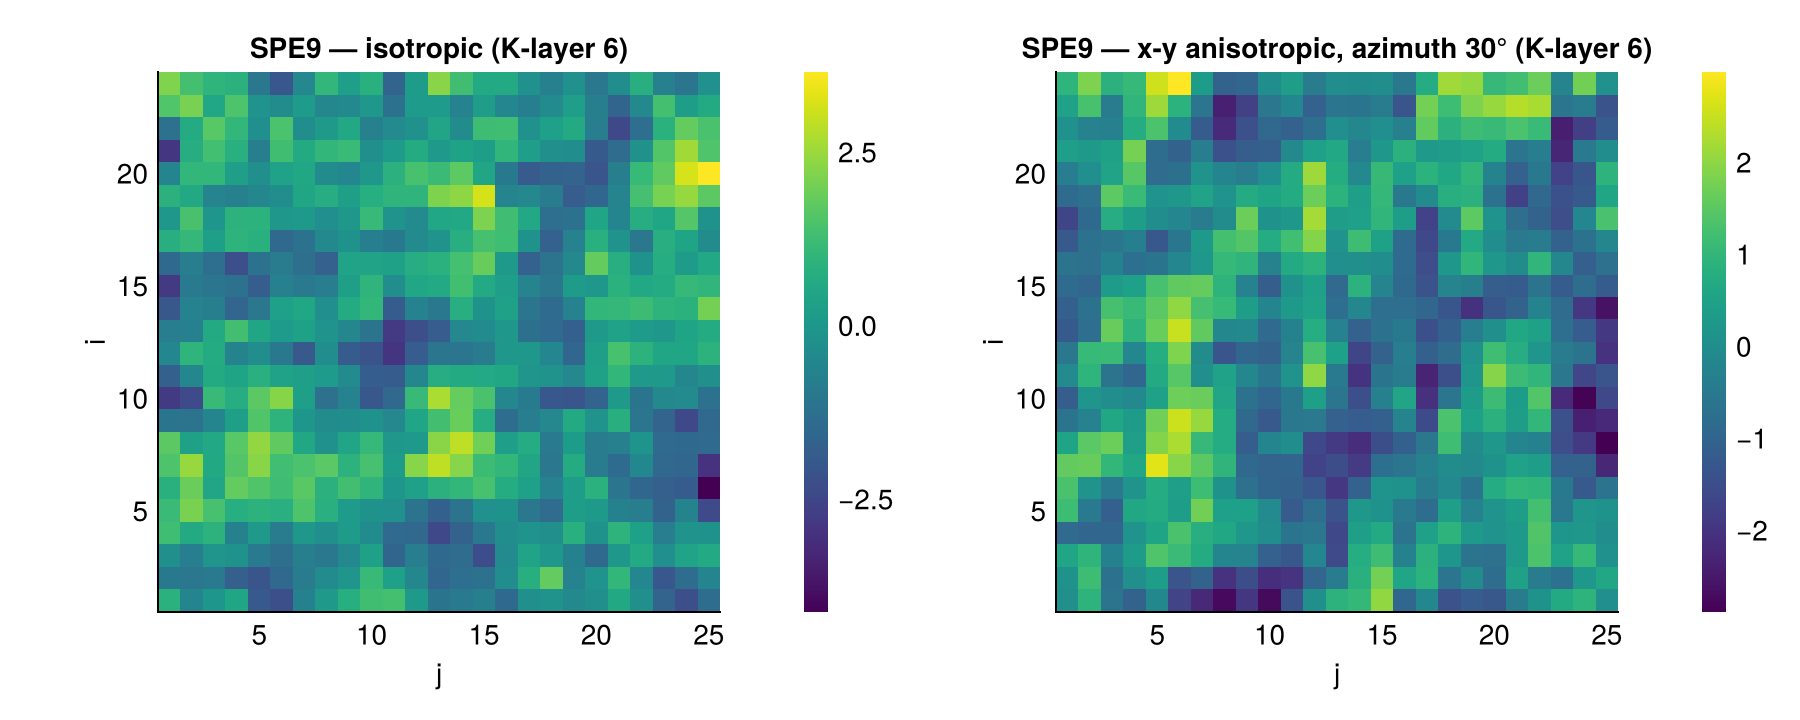

In [4]:
spe9_path = resolve_model_data("SPE9_DATA", "SPE9.DATA", "spe9")
println("SPE9 model: ", spe9_path)
res_spe9 = run_matern_example(spe9_path, "SPE9"; ρ0_frac = 0.25);

---
## Example 2 — NORNE

The Norne field model (`NORNE_ATW2013.DATA`) is a full-field corner-point grid with ≈44 000 active cells in UTM metres. The avgMPFA full-tensor assembly and the 44k×44k sparse Cholesky are both tractable (tens of seconds). We use a smaller range fraction (15% of the lateral extent) since the model is much larger.

NORNE model: /home/AD.NORCERESEARCH.NO/krfo/CodeProjects/makeSENSE/models/opm-tests/norne/NORNE_ATW2013.DATA
=== NORNE ===
active cells = 

44417   grid (ni,nj,nk) = (41, 102, 22)
lateral extent = 7118.8 × 7728.5   vertical = 594.5
ρ0 = 1067.8
Transmissibility:

 Replaced 2 non-finite half-transmissibilities (out of 268308, 0.0%) with zero.


Transmissibility: Replaced 2 non-finite half-transmissibilities (out of 268308, 0.0%) with zero.
isotropic Q nnz = 1121321

   realized var/target: mean = 1.563
empirical marginal std = 

1.253


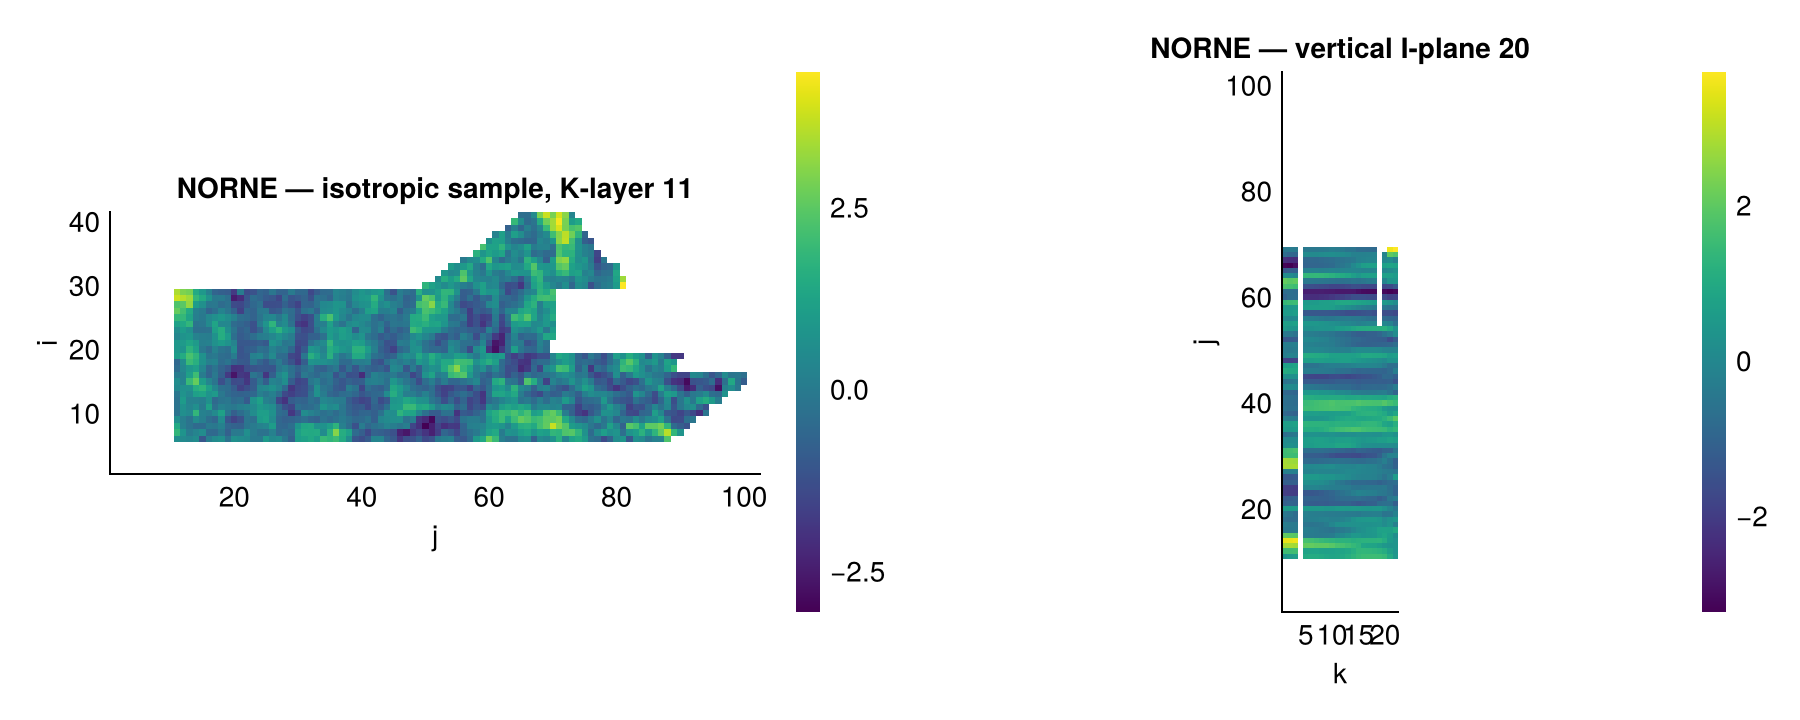

building avgMPFA anisotropic operator ... 

Transmissibility: Replaced 2 non-finite half-transmissibilities (out of 268308, 0.0%) with zero.


Transmissibility: Replaced 2 non-finite half-transmissibilities (out of 268308, 0.0%) with zero.
done. nnz = 2601715

   dip = 0.0°, rake = 0.0°


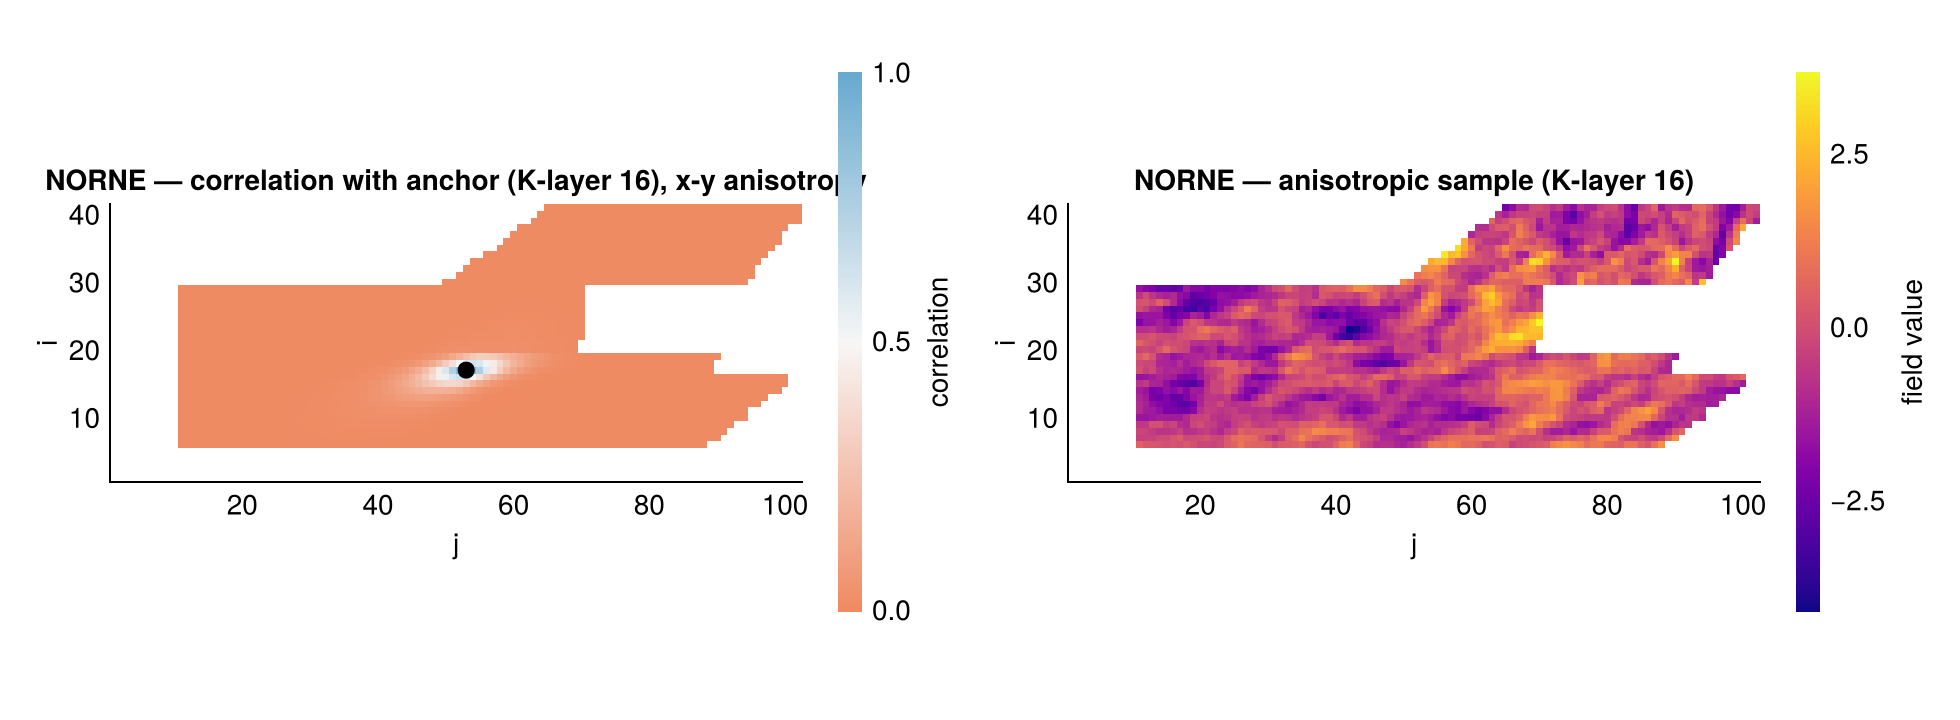

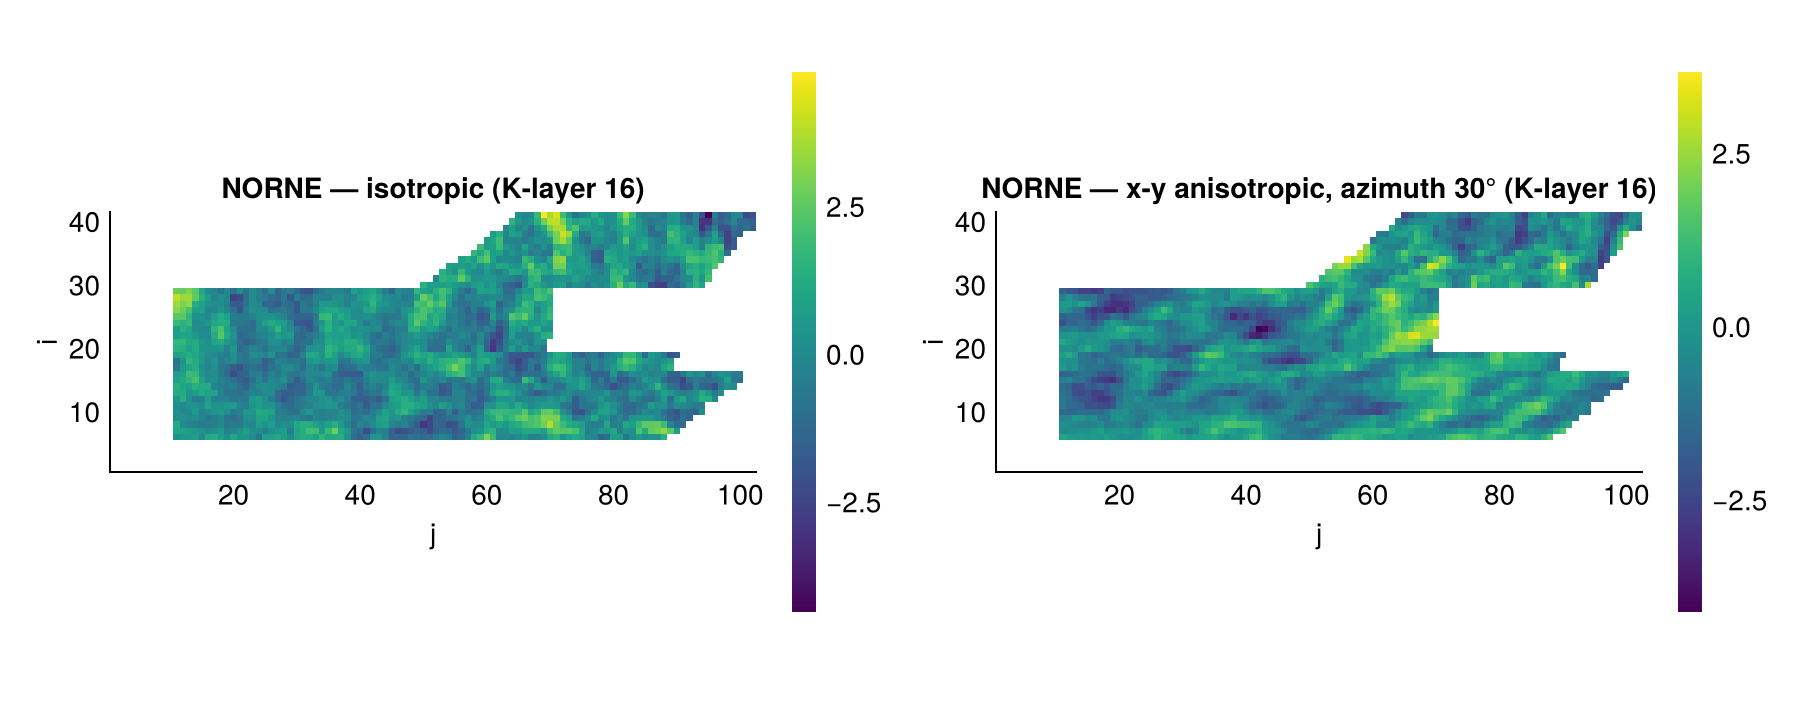

In [5]:
norne_path = resolve_model_data("NORNE_DATA", "NORNE_ATW2013.DATA", "norne")
println("NORNE model: ", norne_path)
res_norne = run_matern_example(norne_path, "NORNE"; ρ0_frac = 0.15);

---
## Example 3 — Target standard deviation $\sigma = 10$

All previous cases used the default marginal standard deviation $\sigma_0 = 1$. Here we set the **target $\sigma_0 = 10$** and check whether the realized marginal standard deviation actually reaches it.

The precision scales as $\tau \propto 1/\sigma$, so $Q \propto 1/\sigma^2$ and $Q^{-1} \propto \sigma^2$: the realized variance is expected to scale linearly with the target. Variance matching is **independent of the anisotropy direction** (anisotropy only reshapes the correlation structure), so we assess on the cheaper isotropic operators. We compare:
- the *analytic* realized marginal std from $\sqrt{\mathrm{diag}(Q^{-1})}$, and
- the *empirical* per-cell std from Monte-Carlo samples.

(v1 uses the analytic $\tau$ with the Robin boundary correction and no Gauss–Newton calibration — see ADR 0003 — so a small systematic offset from the target is expected.)

In [6]:
function assess_sigma_target(data_path::AbstractString, name::AbstractString;
        σ0::Real = 10.0, ρ0_frac::Real = 0.25, n_samples::Integer = 50)
    println("=== ", name, "   (target σ = ", σ0, ") ===")
    domain = load_domain_quiet(data_path)
    nc = number_of_cells(domain); cc = Matrix{Float64}(domain[:cell_centroids])
    lx = maximum(cc[1,:]) - minimum(cc[1,:]); ly = maximum(cc[2,:]) - minimum(cc[2,:])
    ρ0 = ρ0_frac * min(lx, ly)
    prior = MaternSPDE3Prior(nc; ρ0 = ρ0, σ0 = σ0, diffusion_scheme = :tpfa)
    op = matern_spde_operator(domain, prior; compensated = false, boundary = :robin)
    Q = sparse(op.Q)
    v = matern_realized_variance(domain, prior; anchors = :all, compensated = false, boundary = :robin)
    realized_std = sqrt.(v.realized)
    X = sample_prior(Q, n_samples; rng = rng)
    emp_std = vec(std(X, dims = 2))
    r = realized_std ./ σ0
    println("  target σ                          = ", σ0)
    println("  realized std  (diag Q⁻¹):  mean = ", round(mean(realized_std), digits = 3),
            "   min = ", round(minimum(realized_std), digits = 3),
            "   max = ", round(maximum(realized_std), digits = 3))
    println("  ratio realized/target:     mean = ", round(mean(r), digits = 3),
            "   (1.000 = on target)")
    println("  empirical MC std (n=$n_samples):   mean = ", round(mean(emp_std), digits = 3))
    return (name = name, target = Float64(σ0), realized_std = realized_std,
            emp_std = emp_std, ratio_mean = mean(r))
end;

In [7]:
spe9_s10  = assess_sigma_target(spe9_path,  "SPE9";  σ0 = 10.0, ρ0_frac = 0.25)
norne_s10 = assess_sigma_target(norne_path, "NORNE"; σ0 = 10.0, ρ0_frac = 0.15);

=== SPE9

   (target σ = 10.0) ===
  target σ                          = 10.0


  realized std  (diag Q⁻¹):  mean = 11.807   min = 11.344   max = 14.079
  ratio realized/target:     mean = 1.181   (1.000 = on target)
  empirical MC std (n=50):   mean = 11.627
=== NORNE   (target σ = 10.0) ===


Transmissibility: Replaced 2 non-finite half-transmissibilities (out of 268308, 0.0%) with zero.
Transmissibility:

 Replaced 2 non-finite half-transmissibilities (out of 268308, 0.0%) with zero.
  target σ                          = 

10.0
  realized std  (diag Q⁻¹):  mean = 12.454   min = 10.18   max = 28.652
  ratio realized/target:     mean = 1.245   (1.000 = on target)
  empirical MC std (n=50):   mean = 12.305


### Assessment: do the models reach $\sigma = 10$?

The distribution of the cell-wise realized standard deviation should sit close to the target line at 10. A tight histogram centred near 10 (mean ratio ≈ 1) means the target is reached; the residual offset is the uncalibrated analytic-$\tau$ bias.

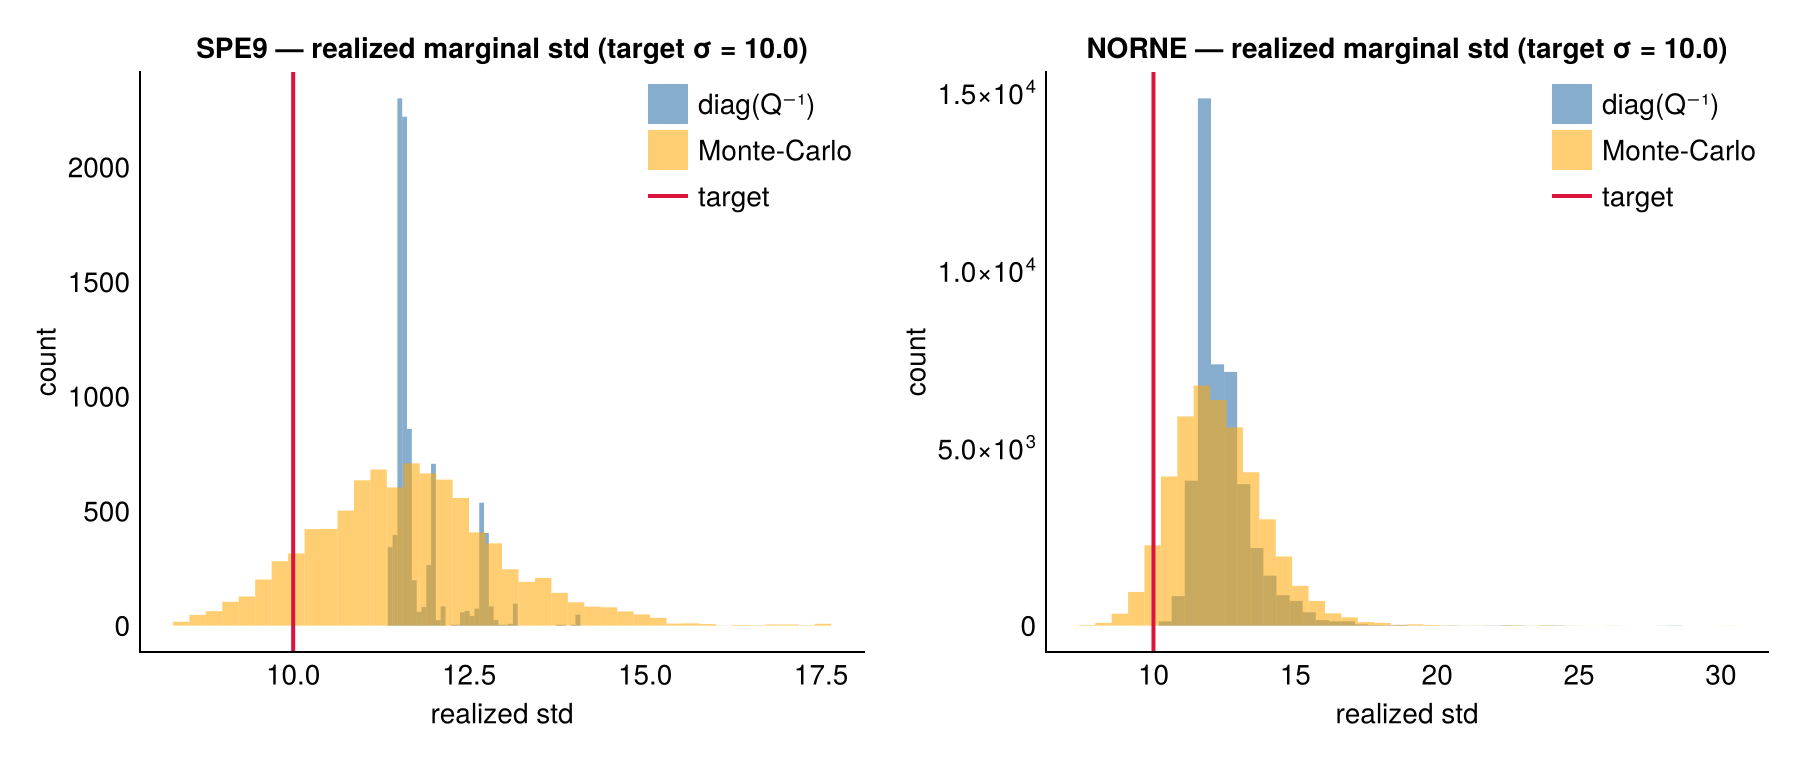

Mean ratio realized/target:  SPE9 = 1.181

   NORNE = 1.245


In [8]:
fig = Figure(size = (900, 380))
for (k, res) in enumerate((spe9_s10, norne_s10))
    ax = Axis(fig[1, k];
        title = "$(res.name) — realized marginal std (target σ = $(res.target))",
        xlabel = "realized std", ylabel = "count")
    hist!(ax, res.realized_std; bins = 40, color = (:steelblue, 0.65), label = "diag(Q⁻¹)")
    hist!(ax, res.emp_std; bins = 40, color = (:orange, 0.55), label = "Monte-Carlo")
    vlines!(ax, [res.target]; color = :crimson, linewidth = 2, label = "target")
    axislegend(ax; position = :rt)
end
display(fig)
println("Mean ratio realized/target:  SPE9 = ", round(spe9_s10.ratio_mean, digits=3),
        "   NORNE = ", round(norne_s10.ratio_mean, digits=3))

---
## Separate demonstration — σ = 10 with 3D mean-SD compensation

The previous σ = 10 experiment is intentionally **uncalibrated**. Here we repeat the standard-deviation check separately with the implemented 3D `matern_sd_compensation!` mean correction. The compensation is calibrated using the same Robin boundary treatment that is used for the final operator.

This is a scalar mean correction in `log(τ)`: it tests whether the overall standard-deviation level can be brought to 10, but it does not perform per-cell variance calibration.

In [9]:
function assess_sigma_compensated(data_path::AbstractString, name::AbstractString;
        σ0::Real = 10.0, ρ0_frac::Real = 0.25, n_samples::Integer = 50)
    println("=== ", name, "   (target σ = ", σ0, ", compensated) ===")
    domain = load_domain_quiet(data_path)
    nc = number_of_cells(domain); cc = Matrix{Float64}(domain[:cell_centroids])
    lx = maximum(cc[1,:]) - minimum(cc[1,:]); ly = maximum(cc[2,:]) - minimum(cc[2,:])
    ρ0 = ρ0_frac * min(lx, ly)
    prior = MaternSPDE3Prior(nc; ρ0 = ρ0, σ0 = σ0, diffusion_scheme = :tpfa)
    matern_sd_compensation!(prior, domain; mode = :mean, anchors = :all, boundary = :robin)
    offset = prior.sd_compensation.logtau_offset
    op = matern_spde_operator(domain, prior; compensated = true, boundary = :robin)
    Q = sparse(op.Q)
    v = matern_realized_variance(domain, prior; anchors = :all, compensated = true, boundary = :robin)
    realized_std = sqrt.(v.realized)
    X = sample_prior(Q, n_samples; rng = rng)
    emp_std = vec(std(X, dims = 2))
    ratio = realized_std ./ σ0
    println("  cached log(τ) offset          = ", round(offset, digits = 5),
            "   multiplier = ", round(exp(offset), digits = 5))
    println("  realized std  (diag Q⁻¹):  mean = ", round(mean(realized_std), digits = 3),
            "   min = ", round(minimum(realized_std), digits = 3),
            "   max = ", round(maximum(realized_std), digits = 3))
    println("  ratio realized/target:     mean = ", round(mean(ratio), digits = 3),
            "   (1.000 = on target)")
    println("  empirical MC std (n=$n_samples):   mean = ", round(mean(emp_std), digits = 3))
    return (name = name, target = Float64(σ0), realized_std = realized_std,
            emp_std = emp_std, ratio_mean = mean(ratio), offset = offset)
end;

In [10]:
spe9_s10_comp  = assess_sigma_compensated(spe9_path,  "SPE9";  σ0 = 10.0, ρ0_frac = 0.25)
norne_s10_comp = assess_sigma_compensated(norne_path, "NORNE"; σ0 = 10.0, ρ0_frac = 0.15);

=== SPE9

   (target σ = 10.0, compensated) ===
  cached log(τ) offset          = 0.16537

   multiplier = 1.17983
  realized std  (diag Q⁻¹):  mean = 10.007   min = 9.615   max = 11.933
  ratio realized/target:     mean = 1.001   (1.000 = on target)
  empirical MC std (n=50):   mean = 10.017
=== NORNE   (target σ = 10.0, compensated) ===


Transmissibility: Replaced 2 non-finite half-transmissibilities (out of 268308, 0.0%) with zero.
Transmissibility:

 Replaced 2 non-finite half-transmissibilities (out of 268308, 0.0%) with zero.


Transmissibility: Replaced 2 non-finite half-transmissibilities (out of 268308, 0.0%) with zero.
  cached log(τ) offset          = 0.21613

   multiplier = 1.24126
  realized std  (diag Q⁻¹):  mean = 10.033   min = 8.201   max = 23.083
  ratio realized/target:     mean = 1.003   (1.000 = on target)
  empirical MC std (n=50):   mean = 10.07


### Compensation assessment

The compensated distributions should move from the uncalibrated means (SPE9 ≈ 11.8 and NORNE ≈ 12.5) toward the target line at 10. The Monte-Carlo means provide an independent check of the compensated precision.

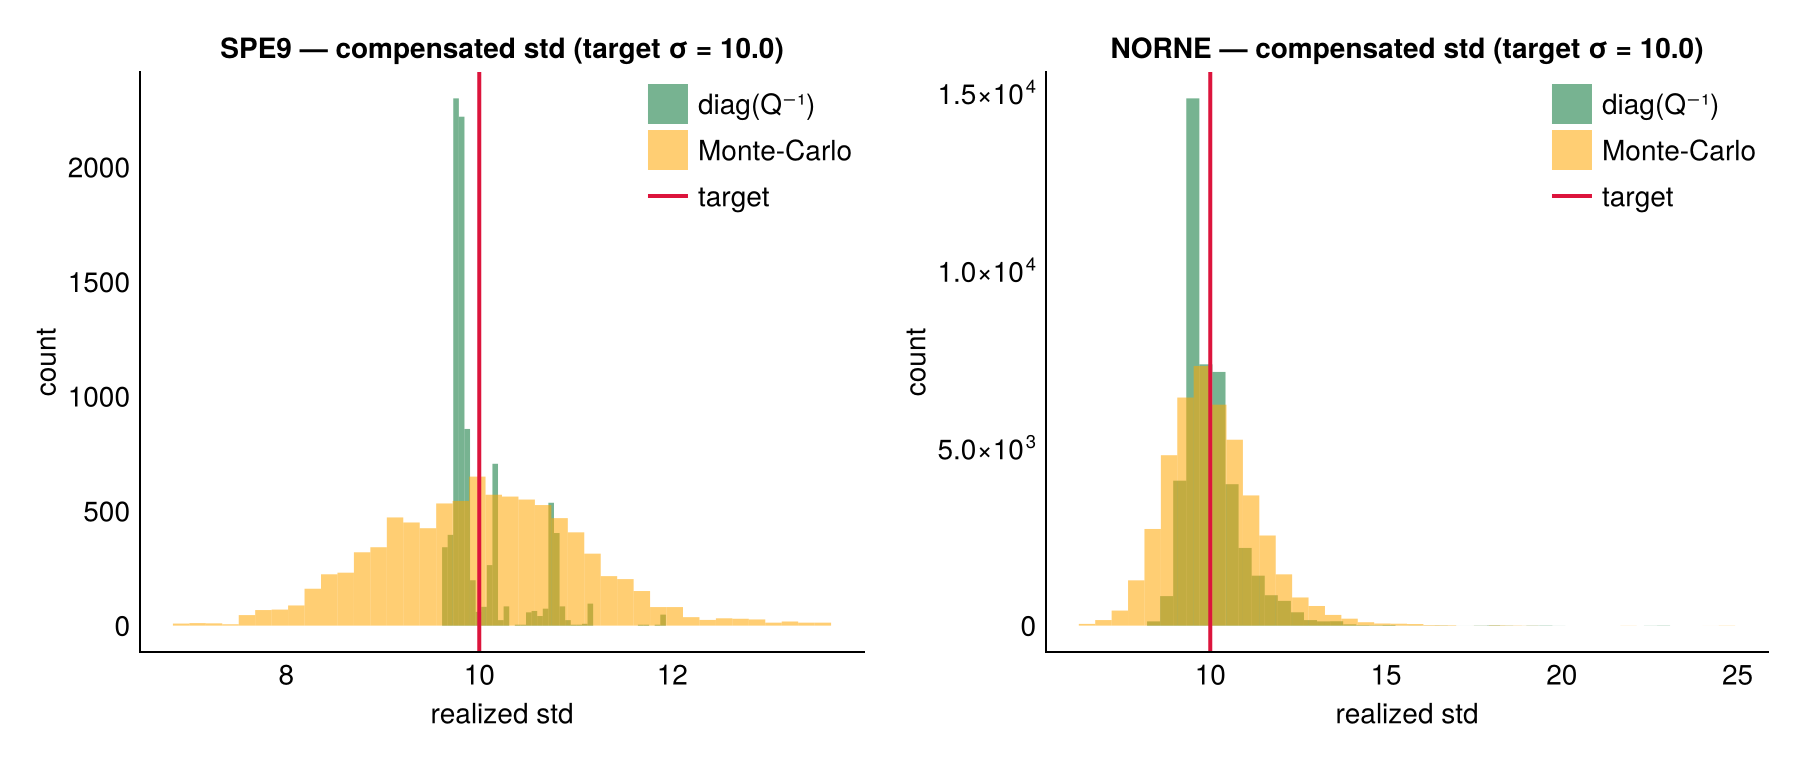

Compensated mean ratio realized/target:  SPE9 = 1.001   NORNE = 1.003


In [11]:
fig_comp = Figure(size = (900, 380))
for (k, res) in enumerate((spe9_s10_comp, norne_s10_comp))
    ax = Axis(fig_comp[1, k];
        title = "$(res.name) — compensated std (target σ = $(res.target))",
        xlabel = "realized std", ylabel = "count")
    hist!(ax, res.realized_std; bins = 40, color = (:seagreen, 0.65), label = "diag(Q⁻¹)")
    hist!(ax, res.emp_std; bins = 40, color = (:orange, 0.55), label = "Monte-Carlo")
    vlines!(ax, [res.target]; color = :crimson, linewidth = 2, label = "target")
    axislegend(ax; position = :rt)
end
display(fig_comp)
println("Compensated mean ratio realized/target:  SPE9 = ", round(spe9_s10_comp.ratio_mean, digits=3),
        "   NORNE = ", round(norne_s10_comp.ratio_mean, digits=3))

## Summary

Both models were carried through the same two field experiments, the original uncalibrated $\sigma = 10$ check, and a separate compensated $\sigma = 10$ demonstration:

In [12]:
println("Field experiments:")
for r in (res_spe9, res_norne)
    println("  ", r.name, ": nc = ", r.nc, "  grid = ", r.grid,
            "  ρ0 = ", round(r.ρ0, digits=1),
            "  ρ_major/ρ_minor = ", round(r.ρ_major/r.ρ_minor, digits=2),
            "  azimuth = ", round(rad2deg(r.azimuth), digits=1), "°")
end
println("σ = 10 target check (mean realized std / 10):")
for r in (spe9_s10, norne_s10)
    println("  ", r.name, ": ", round(r.ratio_mean, digits=3),
            "   (mean realized std = ", round(mean(r.realized_std), digits=2), ")")
end

Field experiments:
  SPE9

: nc = 9000  grid = (24, 25, 15)  ρ0 = 525.8  ρ_major/ρ_minor = 2.86  azimuth = 30.0°
  NORNE: nc = 44417  grid = (41, 102, 22)  ρ0 = 1067.8  ρ_major/ρ_minor = 2.86  azimuth = 30.0°
σ = 10 target check (mean realized std / 10):
  SPE9: 1.181   (mean realized std = 11.81)
  NORNE: 1.245   (mean realized std = 12.45)


## Next steps

- The one-call `.DATA`-to-CSC API `matern_precision_from_data_file_3d` runs this whole pipeline and returns the sparse precision; it is the entry point used by the Python helper `jutuldarcy_matern.matern_precision_from_data_file_3d`.
- Per-cell (nonstationary) variance/range/orientation fields can be supplied as length-`nc` vectors.
- The separate compensated $\sigma = 10$ demonstration shows that the implemented 3D mean-SD compensation reduces the mean ratios to approximately 1.00 for both models. Full 3D Gauss–Newton calibration remains deferred in v1 (see ADR 0003).
- To tilt the anisotropy out of the x–y plane, set a non-zero `dip` (and optionally `rake`); the avgMPFA scheme handles the full 3D rotation of $\Theta$.
- See `docs/adr/` for the design rationale behind the avgMPFA discretization, Robin boundary correction, and the analytic-$\tau$ v1.